In [35]:
#Importacion de Librerias
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Audio
import soundfile as sf
from numpy import pi
import os
import pandas as pd
import torchaudio
import torch
import gc
import os
from scipy.signal import butter, sosfilt
from IPython.display import Audio, display
import seaborn as sns
import matplotlib.pyplot as plt
import re

torch.cuda.get_device_name(0)

path = "./2/Respiratory_Sound_Database/Respiratory_Sound_Database"

# Funciones utiles
---

In [314]:
def histograms(df, column, xlabel, bins=50):
    df[column].hist(bins=bins, edgecolor='black')
    plt.grid()
    plt.title(xlabel)
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia")
    
    plt.figure()
    devices = [
        "LittC2SE",
        "AKGC417L",
        "Meditron",
        "Litt3200"
    ]
    # Crear figura con 2 filas × 2 columnas
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=False)

    for ax, device in zip(axes.ravel(), devices):
        # Filtrar SNR para este dispositivo
        snrs = df[df["device"] == device][column]
        
        # Dibujar histograma
        ax.hist(snrs, bins=bins, edgecolor='black')
        ax.set_title(device)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecuencia")

# Data cleaning
---

## Extracción de metadata

In [103]:
def parse_filename(fname):
    fname = str(fname)
    name = os.path.splitext(fname)[0]
    pattern = (
        r"^(?P<patient>\d{3})_"
        r"(?P<rec_idx>\d[A-z]\d+)_"
        r"(?P<loc>Tc|Al|Ar|Pl|Pr|Ll|Lr)_"
        r"(?P<mode>sc|mc)_"
        r"(?P<device>.+)$"
    )
    m = re.match(pattern, name)
    if not m:
        return None
    return {
        "filename":    fname,
        "patient":     int(m.group("patient")),
        "rec_idx":     m.group("rec_idx"),
        "chest_loc":   m.group("loc"),
        "mode":        m.group("mode"),
        "device":      m.group("device")
    }

In [132]:
def compute_snr(signal):
    signal_power = np.mean(signal ** 2)
    noise_estimate = np.median(np.abs(signal - np.median(signal)))
    noise_power = noise_estimate ** 2 + 1e-10
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

In [281]:
def bandpass_filter(signal, sr, lowcut=20, highcut=250, order=4):
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=sr, output='sos')
    return sosfilt(sos, signal)

In [282]:
def extract_tone_metrics(seg, sr):
    # FFT
    S     = np.abs(np.fft.rfft(seg))
    freqs = np.fft.rfftfreq(len(seg), 1/sr)
    # Frecuencia dominante
    idx_peak = np.argmax(S)
    dom_freq = freqs[idx_peak]
    # Ancho de banda a -3 dB
    peak_mag = S[idx_peak]
    mask     = S >= (peak_mag / np.sqrt(2))
    bandwidth = freqs[mask].max() - freqs[mask].min()
    # Spectral flatness
    flat = librosa.feature.spectral_flatness(y=seg, n_fft=1024, hop_length=512).mean()
    return dom_freq, bandwidth, flat

In [283]:
AUDIO_DIR = path + "/audio_and_txt_files"

devices = [
    "LittC2SE",
    "AKGC417L",
    "Meditron",
    "Litt3200"
]

rows = []
for fname in os.listdir(AUDIO_DIR):
    if not fname.lower().endswith(".wav"):
        continue
    
    meta = parse_filename(fname)
    if meta is None:
        print("None", fname)
        continue

    wav_path = os.path.join(AUDIO_DIR, fname)
    txt_path = os.path.join(AUDIO_DIR, os.path.splitext(fname)[0] + ".txt")

    # Obtener duración total
    info = torchaudio.info(wav_path)
    full_dur = info.num_frames / info.sample_rate

    # Leer segmentos anotados
    if not os.path.exists(txt_path):
        continue

    with open(txt_path, "r") as f:
        for line in f:
            start, end, crackle, wheeze = map(float, line.split())
            seg_dur = end - start

            # Cargar sólo el segmento
            waveform, sr = torchaudio.load(
                wav_path,
                frame_offset=int(start * info.sample_rate),
                num_frames=int(seg_dur * info.sample_rate)
            )
            # Convertir a numpy
            seg = waveform[0].numpy()

            # Filtrado pasa-bajos
            seg_filt = bandpass_filter(seg, sr)


            # Cálculo de SNR
            snr_db = compute_snr(seg_filt)

            # Métricas tonales
            dom_freq, bandwidth, flatness = extract_tone_metrics(seg_filt, sr)

            row = {
                **meta,
                "segment_start_s":        start,
                "segment_end_s":          end,
                "segment_duration_s":     seg_dur,
                "full_audio_duration_s":  full_dur,
                "crackles":               int(crackle),
                "wheezes":                int(wheeze),
                "snr_db":                 round(snr_db, 2),
                "dom_freq_hz":            round(dom_freq, 1),
                "bandwidth_hz":           round(bandwidth, 1),
                "spectral_flatness":      round(flatness, 4),
            }
            rows.append(row)


In [284]:
df = pd.DataFrame(rows)
df

,filename,patient,rec_idx,chest_loc,mode,device,segment_start_s,segment_end_s,segment_duration_s,full_audio_duration_s,crackles,wheezes,snr_db,dom_freq_hz,bandwidth_hz,spectral_flatness
0,189_1b2_Lr_mc_LittC2SE.wav,189,1b2,Lr,mc,LittC2SE,0.022,4.764,4.742,20.0,1,0,5.00,34.2,29.7,0.0
1,189_1b2_Lr_mc_LittC2SE.wav,189,1b2,Lr,mc,LittC2SE,4.764,9.621,4.857,20.0,1,0,5.34,36.2,7.2,0.0
2,189_1b2_Lr_mc_LittC2SE.wav,189,1b2,Lr,mc,LittC2SE,9.621,14.921,5.300,20.0,0,0,6.26,32.5,9.4,0.0
3,189_1b2_Lr_mc_LittC2SE.wav,189,1b2,Lr,mc,LittC2SE,14.921,19.579,4.658,20.0,0,0,6.33,29.2,10.5,0.0
4,189_1b2_Lr_mc_LittC2SE.wav,189,1b2,Lr,mc,LittC2SE,19.579,19.936,0.357,20.0,0,0,4.39,36.4,19.6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6893,123_1b1_Al_sc_Meditron.wav,123,1b1,Al,sc,Meditron,8.207,10.779,2.572,20.0,0,0,10.19,39.7,12.8,0.0
6894,123_1b1_Al_sc_Meditron.wav,123,1b1,Al,sc,Meditron,10.779,14.279,3.500,20.0,0,0,9.42,40.3,16.3,0.0
6895,123_1b1_Al_sc_Meditron.wav,123,1b1,Al,sc,Meditron,14.279,16.779,2.500,20.0,0,0,9.90,27.2,24.0,0.0
6896,123_1b1_Al_sc_Meditron.wav,123,1b1,Al,sc,Meditron,16.779,19.450,2.671,20.0,0,0,9.59,42.3,8.2,0.0


In [285]:
df.sort_values("snr_db")


,filename,patient,rec_idx,chest_loc,mode,device,segment_start_s,segment_end_s,segment_duration_s,full_audio_duration_s,crackles,wheezes,snr_db,dom_freq_hz,bandwidth_hz,spectral_flatness
4756,204_7p5_Pr_mc_AKGC417L.wav,204,7p5,Pr,mc,AKGC417L,0.077,2.9820,2.9050,20.000,0,0,0.13,49.9,0.0,0.0040
208,130_3p2_Pr_mc_AKGC417L.wav,130,3p2,Pr,mc,AKGC417L,1.461,2.9180,1.4570,20.000,1,0,0.62,50.1,0.0,0.0000
213,130_3p2_Pr_mc_AKGC417L.wav,130,3p2,Pr,mc,AKGC417L,14.492,17.3890,2.8970,20.000,1,0,0.66,50.1,0.0,0.0000
209,130_3p2_Pr_mc_AKGC417L.wav,130,3p2,Pr,mc,AKGC417L,2.918,5.8390,2.9210,20.000,1,0,0.69,50.0,0.0,0.0000
4405,163_2b2_Pr_mc_AKGC417L.wav,163,2b2,Pr,mc,AKGC417L,17.369,19.9580,2.5890,20.000,0,0,0.69,49.8,0.4,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,113_1b1_Lr_sc_Litt3200.wav,113,1b1,Lr,sc,Litt3200,0.000,1.8667,1.8667,14.576,0,0,24.69,52.5,36.4,0.0000
5120,130_3b4_Ar_mc_AKGC417L.wav,130,3b4,Ar,mc,AKGC417L,9.958,14.0790,4.1210,20.000,0,0,25.19,23.8,9.2,0.0000
5119,130_3b4_Ar_mc_AKGC417L.wav,130,3b4,Ar,mc,AKGC417L,5.925,9.9580,4.0330,20.000,0,0,26.48,18.1,5.7,0.0000
3645,130_3p2_Ar_mc_AKGC417L.wav,130,3p2,Ar,mc,AKGC417L,17.389,18.7960,1.4070,20.000,0,0,28.40,40.5,33.4,0.0000


## Análisis SNR

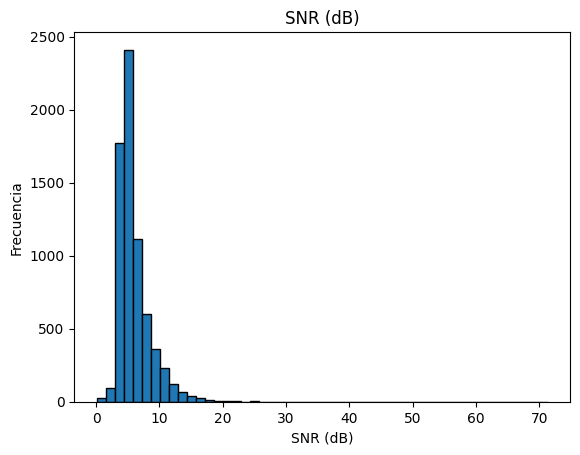

<Figure size 640x480 with 0 Axes>

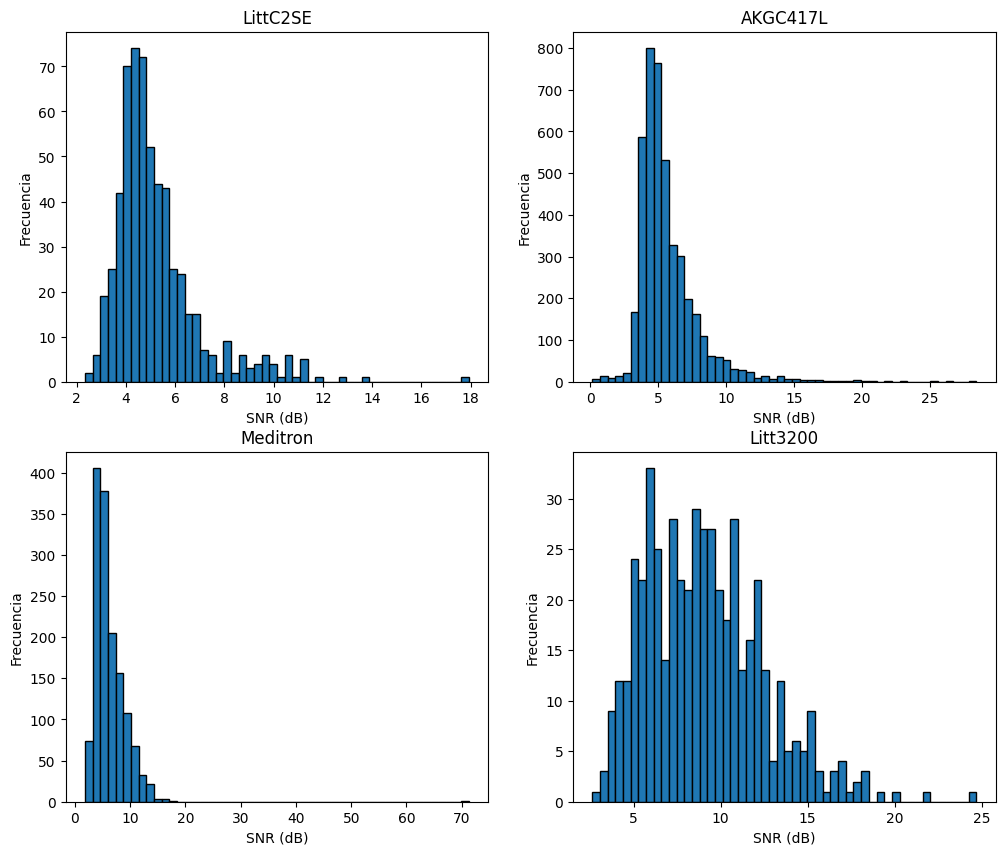

In [315]:
histograms(df, "snr_db", "SNR (dB)", bins=50)

In [287]:
for device in devices:
    sub = df[df["device"] == device].dropna(subset=["snr_db"])
    if sub.empty:
        continue

    # Peor y mejor SNR
    worst = sub.nsmallest(1, "snr_db").iloc[0]
    best  = sub.nlargest(1,  "snr_db").iloc[0]

    print(f"\n____{device}____")
    print(f"Peor SNR: {worst['snr_db']} dB — Archivo: {worst['filename']} — Segmento: {worst['segment_start_s']:.2f}-{worst['segment_start_s']+worst['segment_duration_s']:.2f} s")
    print(f"Mejor SNR: {best ['snr_db']} dB — Archivo: {best ['filename']} — Segmento: {best ['segment_start_s']:.2f}-{best ['segment_start_s']+best ['segment_duration_s']:.2f} s")

    # Función para cargar y reproducir el segmento
    def play_segment(row):
        path = os.path.join(AUDIO_DIR, row["filename"])
        offset = int(row["segment_start_s"] * row["full_audio_duration_s"] / row["full_audio_duration_s"] * torchaudio.info(path).sample_rate)
        # mejor usar librosa para frame_offset y num_frames
        waveform, sr = librosa.load(
                path,
                sr=None,
                offset=row["segment_start_s"],
                duration=row["segment_duration_s"]
            )
        return Audio(waveform, rate=sr)

    # Reproducir en notebook
    print("Peor SNR:")
    display(play_segment(worst))
    print("Mejor SNR:")
    display(play_segment(best))


____LittC2SE____
Peor SNR: 2.33 dB — Archivo: 122_2b2_Ar_mc_LittC2SE.wav — Segmento: 19.68-19.98 s
Mejor SNR: 17.94 dB — Archivo: 220_1b2_Al_mc_LittC2SE.wav — Segmento: 0.05-0.85 s
Peor SNR:


Mejor SNR:



____AKGC417L____
Peor SNR: 0.13 dB — Archivo: 204_7p5_Pr_mc_AKGC417L.wav — Segmento: 0.08-2.98 s
Mejor SNR: 28.4 dB — Archivo: 130_3p2_Ar_mc_AKGC417L.wav — Segmento: 17.39-18.80 s
Peor SNR:


Mejor SNR:



____Meditron____
Peor SNR: 1.81 dB — Archivo: 157_1b1_Lr_sc_Meditron.wav — Segmento: 55.22-58.30 s
Mejor SNR: 71.34 dB — Archivo: 166_1p1_Al_sc_Meditron.wav — Segmento: 16.70-32.87 s
Peor SNR:


Mejor SNR:



____Litt3200____
Peor SNR: 2.62 dB — Archivo: 124_1b1_Lr_sc_Litt3200.wav — Segmento: 13.54-17.26 s
Mejor SNR: 24.69 dB — Archivo: 113_1b1_Lr_sc_Litt3200.wav — Segmento: 0.00-1.87 s
Peor SNR:


Mejor SNR:


/tmp/ipykernel_7046/3531182899.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7046/3531182899.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


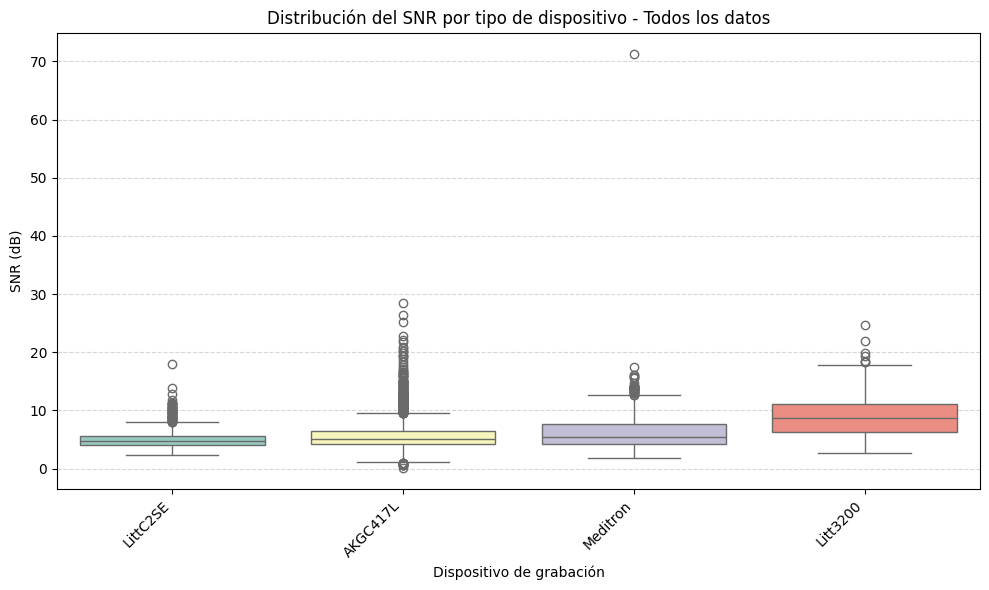

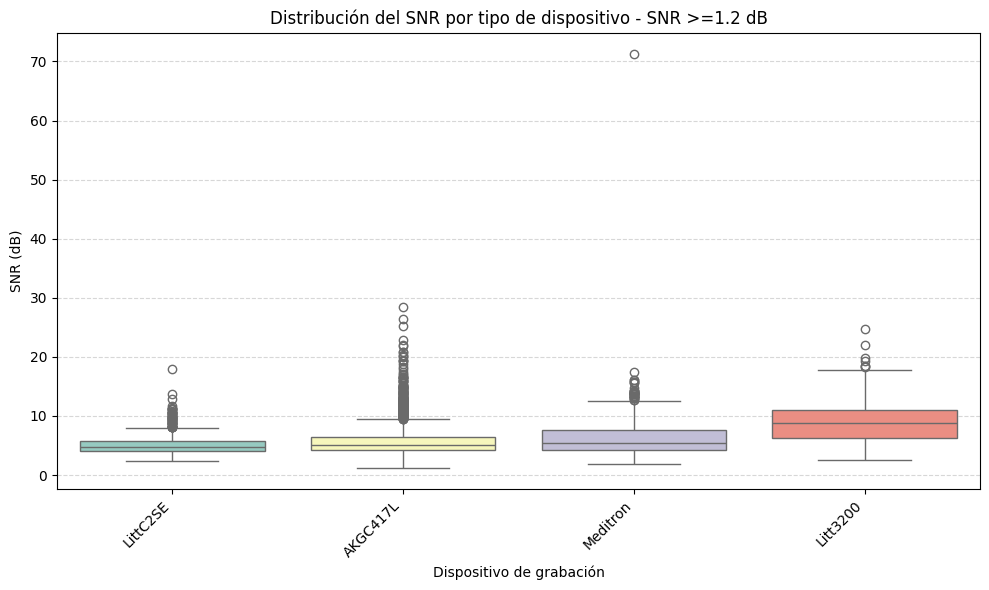

In [288]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="device",
    y="snr_db",
    data=df,
    palette="Set3"
)
plt.xlabel("Dispositivo de grabación")
plt.ylabel("SNR (dB)")
plt.title("Distribución del SNR por tipo de dispositivo - Todos los datos")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.figure(figsize=(10, 6))
sns.boxplot(
    x="device",
    y="snr_db",
    data=df[df["snr_db"]>=1.2],
    palette="Set3"
)
plt.xlabel("Dispositivo de grabación")
plt.ylabel("SNR (dB)")
plt.title("Distribución del SNR por tipo de dispositivo - SNR >=1.2 dB")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

## Análisis de duración

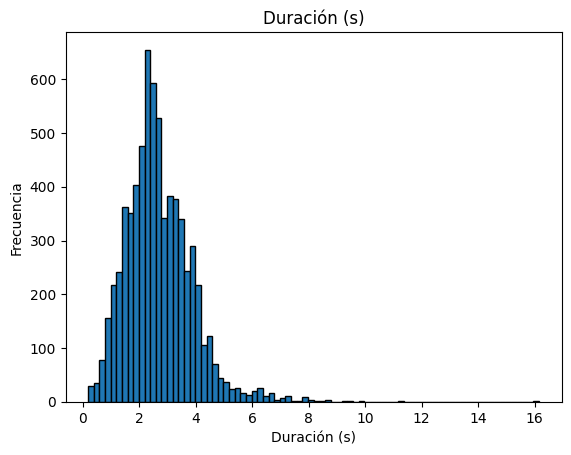

<Figure size 640x480 with 0 Axes>

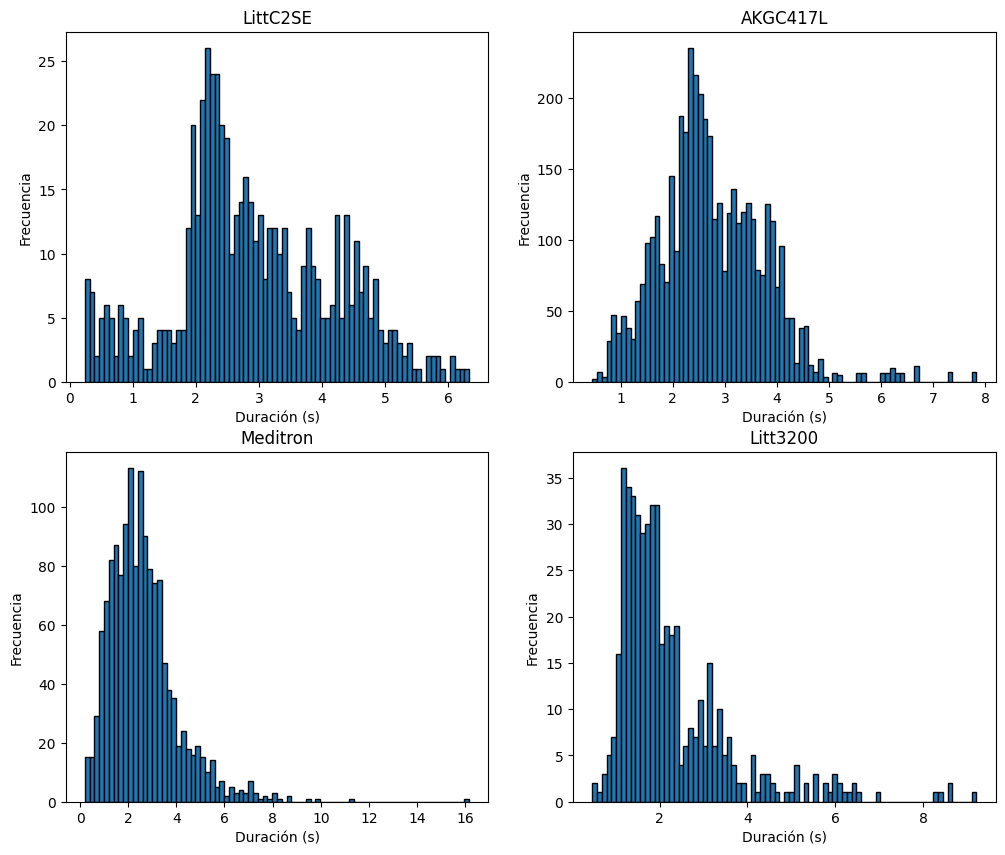

In [316]:
histograms(df, "segment_duration_s", "Duración (s)", bins=80)

In [290]:
for device in devices:
    sub = df[df["device"] == device].dropna(subset=["segment_duration_s"])
    if sub.empty:
        continue
    
    worst = sub.nsmallest(1, "segment_duration_s").iloc[0]
    best  = sub.nlargest(1,  "segment_duration_s").iloc[0]

    print(f"\n____{device}____")
    print(f"Menor duración: {worst['segment_duration_s']} s — Archivo: {worst['filename']} — Segmento: {worst['segment_start_s']:.2f}-{worst['segment_start_s']+worst['segment_duration_s']:.2f} s")
    print(f"Mayor duración: {best ['segment_duration_s']} s — Archivo: {best ['filename']} — Segmento: {best ['segment_start_s']:.2f}-{best ['segment_start_s']+best ['segment_duration_s']:.2f} s")

    # Función para cargar y reproducir el segmento
    def play_segment(row):
        path = os.path.join(AUDIO_DIR, row["filename"])
        offset = int(row["segment_start_s"] * row["full_audio_duration_s"] / row["full_audio_duration_s"] * torchaudio.info(path).sample_rate)
        # mejor usar librosa para frame_offset y num_frames
        waveform, sr = librosa.load(
                path,
                sr=None,
                offset=row["segment_start_s"],
                duration=row["segment_duration_s"]
            )
        return Audio(waveform, rate=sr)

    # Reproducir en notebook
    print("Menor duración:")
    display(play_segment(worst))
    print("Mayor duración:")
    display(play_segment(best))


____LittC2SE____
Menor duración: 0.24299999999999855 s — Archivo: 135_2b3_Tc_mc_LittC2SE.wav — Segmento: 19.75-19.99 s
Mayor duración: 6.328000000000001 s — Archivo: 181_1b2_Ar_mc_LittC2SE.wav — Segmento: 5.19-11.52 s
Menor duración:


Mayor duración:



____AKGC417L____
Menor duración: 0.4519999999999982 s — Archivo: 204_2b5_Ll_mc_AKGC417L.wav — Segmento: 19.53-19.98 s
Mayor duración: 7.830000000000002 s — Archivo: 162_1b2_Pl_mc_AKGC417L.wav — Segmento: 10.79-18.62 s
Menor duración:


Mayor duración:



____Meditron____
Menor duración: 0.1999999999999993 s — Archivo: 217_1b1_Tc_sc_Meditron.wav — Segmento: 19.76-19.96 s
Mayor duración: 16.163 s — Archivo: 166_1p1_Al_sc_Meditron.wav — Segmento: 16.70-32.87 s
Menor duración:


Mayor duración:



____Litt3200____
Menor duración: 0.46199999999999974 s — Archivo: 109_1b1_Lr_sc_Litt3200.wav — Segmento: 16.99-17.46 s
Mayor duración: 9.217 s — Archivo: 175_1b1_Pl_sc_Litt3200.wav — Segmento: 12.46-21.68 s
Menor duración:


Mayor duración:


/tmp/ipykernel_7046/1414286625.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7046/1414286625.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


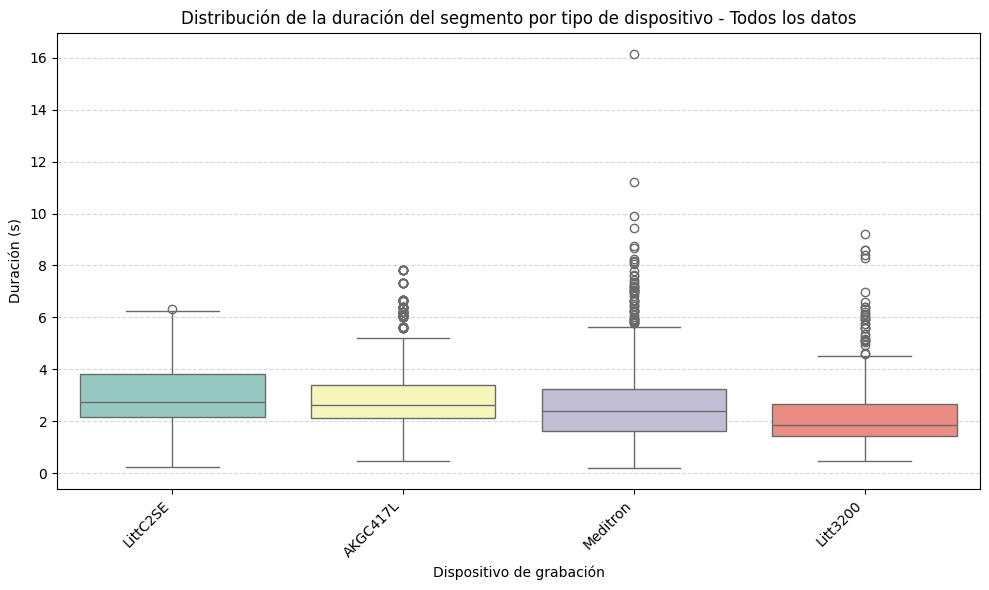

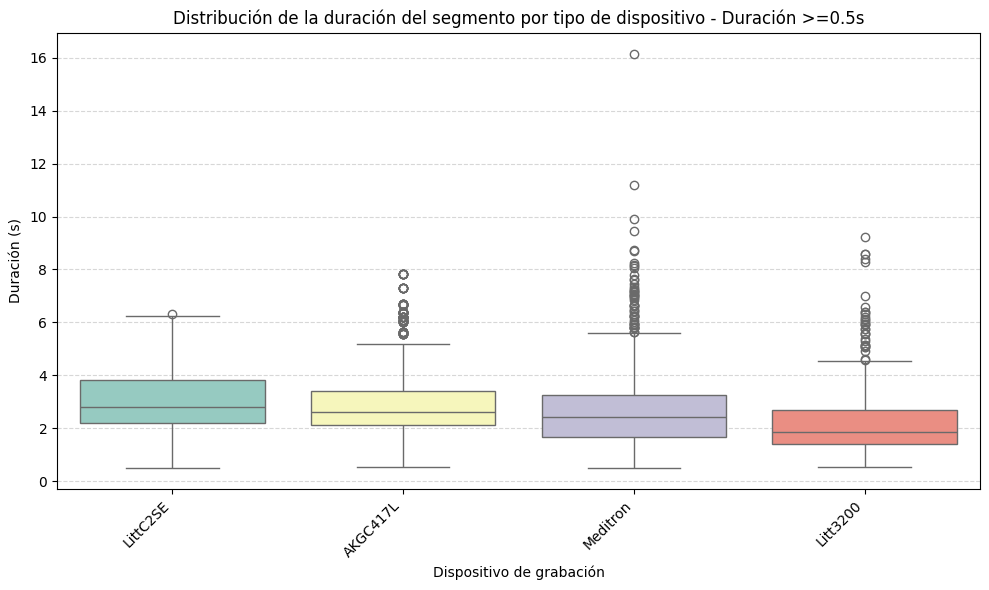

In [291]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="device",
    y="segment_duration_s",
    data=df,
    palette="Set3"
)
plt.xlabel("Dispositivo de grabación")
plt.ylabel("Duración (s)")
plt.title("Distribución de la duración del segmento por tipo de dispositivo - Todos los datos")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.figure(figsize=(10, 6))
sns.boxplot(
    x="device",
    y="segment_duration_s",
    data=df[df["segment_duration_s"]>=0.5],
    palette="Set3"
)
plt.xlabel("Dispositivo de grabación")
plt.ylabel("Duración (s)")
plt.title("Distribución de la duración del segmento por tipo de dispositivo - Duración >=0.5s")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

In [292]:
df[df["segment_duration_s"]<=0.5]["device"].value_counts()

device
Meditron    21
LittC2SE    19
Litt3200     1
AKGC417L     1
Name: count, dtype: int64

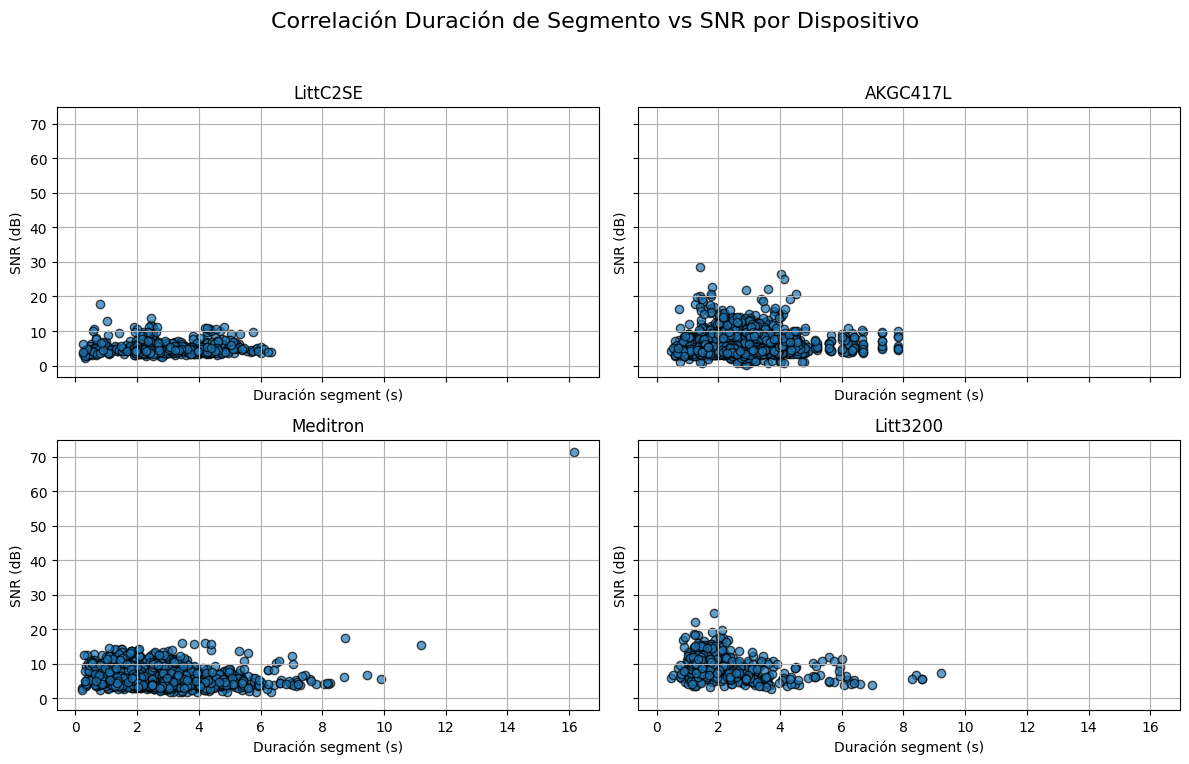

LittC2SE: Coef. Pearson = 0.02
AKGC417L: Coef. Pearson = 0.06
Meditron: Coef. Pearson = 0.03
Litt3200: Coef. Pearson = -0.33


In [293]:
n = len(devices)
cols = 2
rows = (n + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True, sharey=True)

# Aplanar ejes
axes = axes.flatten()

# Graficar para cada dispositivo
for ax, device in zip(axes, devices):
    sub = df[df['device'] == device].dropna(subset=['segment_duration_s', 'snr_db'])
    ax.scatter(sub['segment_duration_s'], sub['snr_db'], alpha=0.7, edgecolor='k')
    ax.set_title(device)
    ax.set_xlabel('Duración segment (s)')
    ax.set_ylabel('SNR (dB)')
    ax.grid(True)

# Si hay ejes extra, eliminarlos
for ax in axes[len(devices):]:
    fig.delaxes(ax)

fig.suptitle('Correlación Duración de Segmento vs SNR por Dispositivo', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Calcular y mostrar correlación por dispositivo
for device in devices:
    sub = df[df['device'] == device].dropna(subset=['segment_duration_s', 'snr_db'])
    corr = sub['segment_duration_s'].corr(sub['snr_db'])
    print(f"{device}: Coef. Pearson = {corr:.2f}")

## Análisis espectral

Filtro 20 a 1999 hz:

* Frecuencia dominante

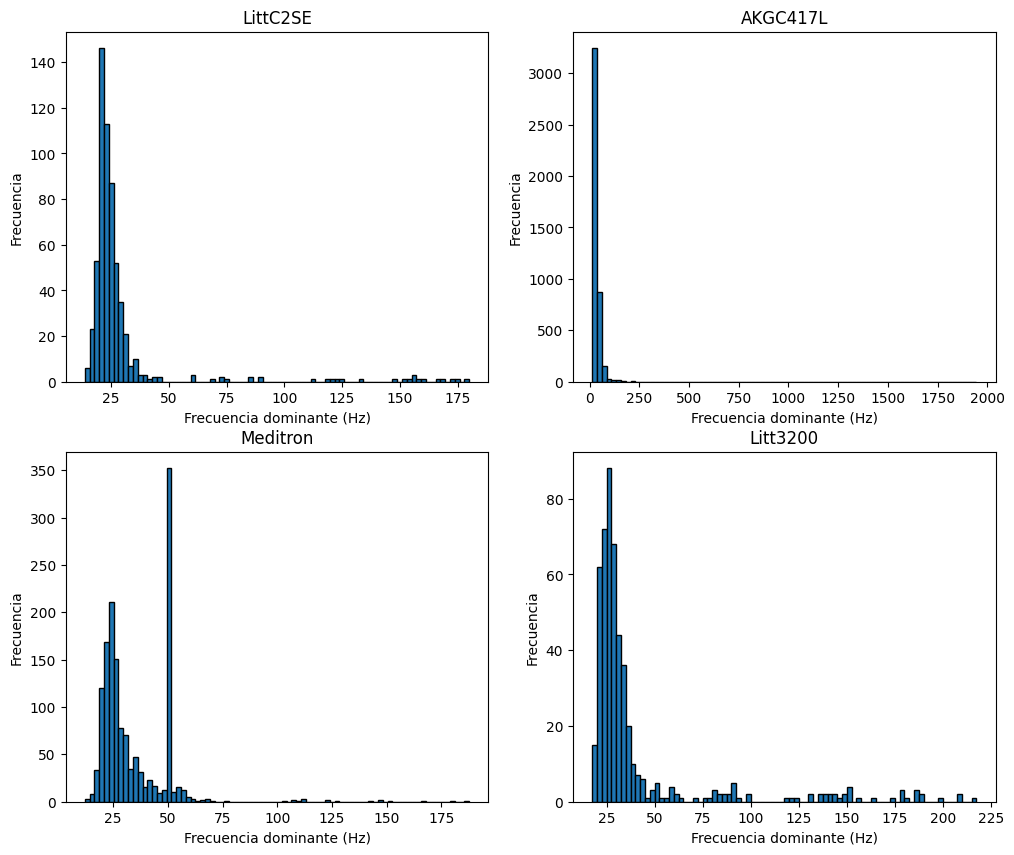

* Bandwith 

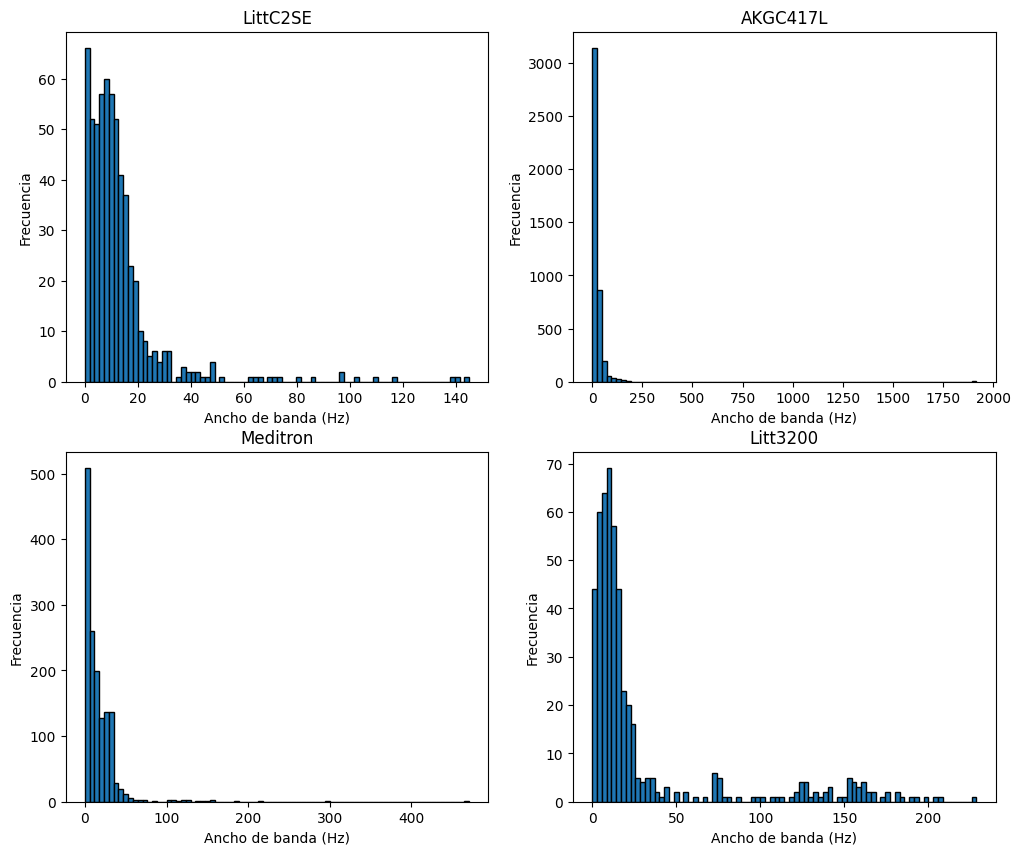

* Planitud espectral 

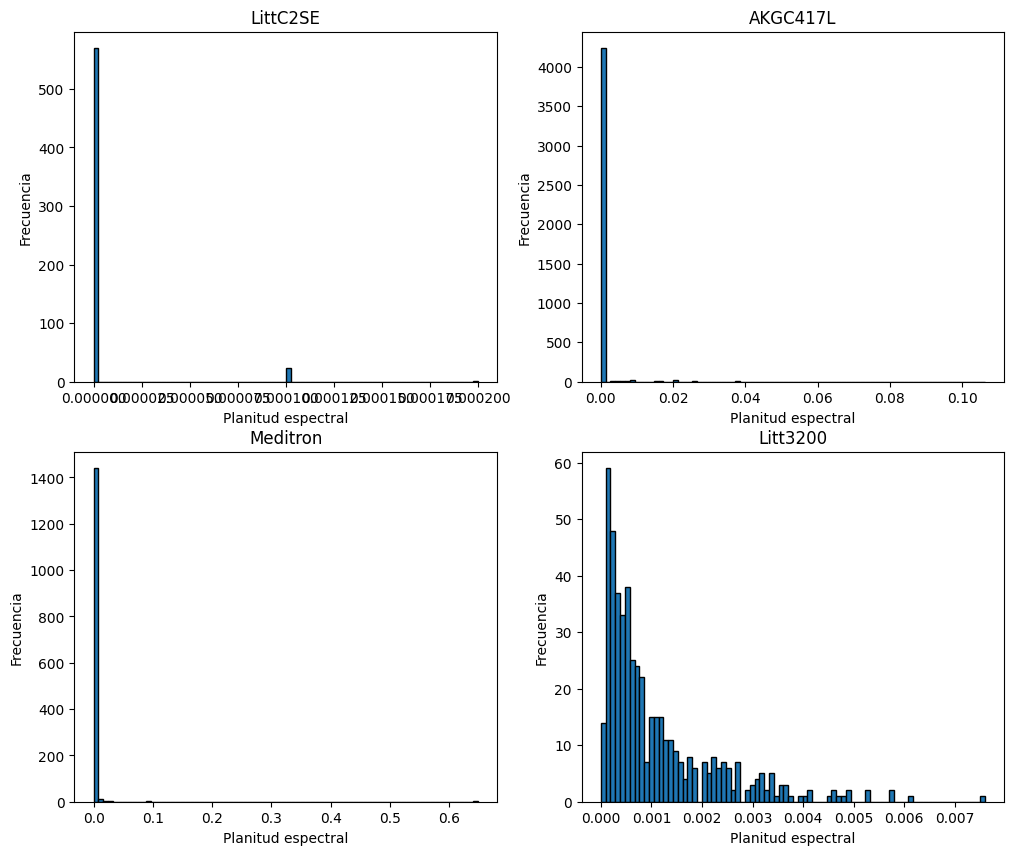

#### Planitud espectral

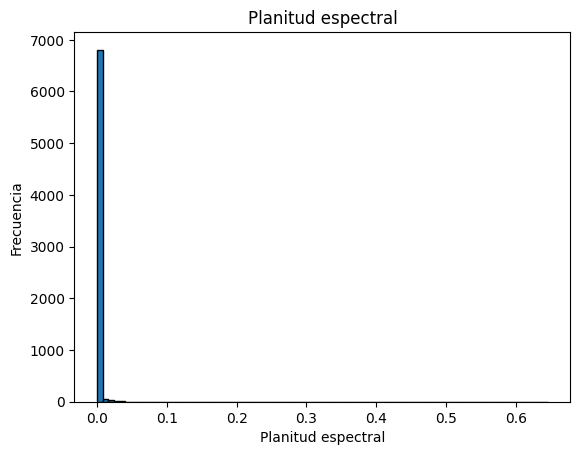

<Figure size 640x480 with 0 Axes>

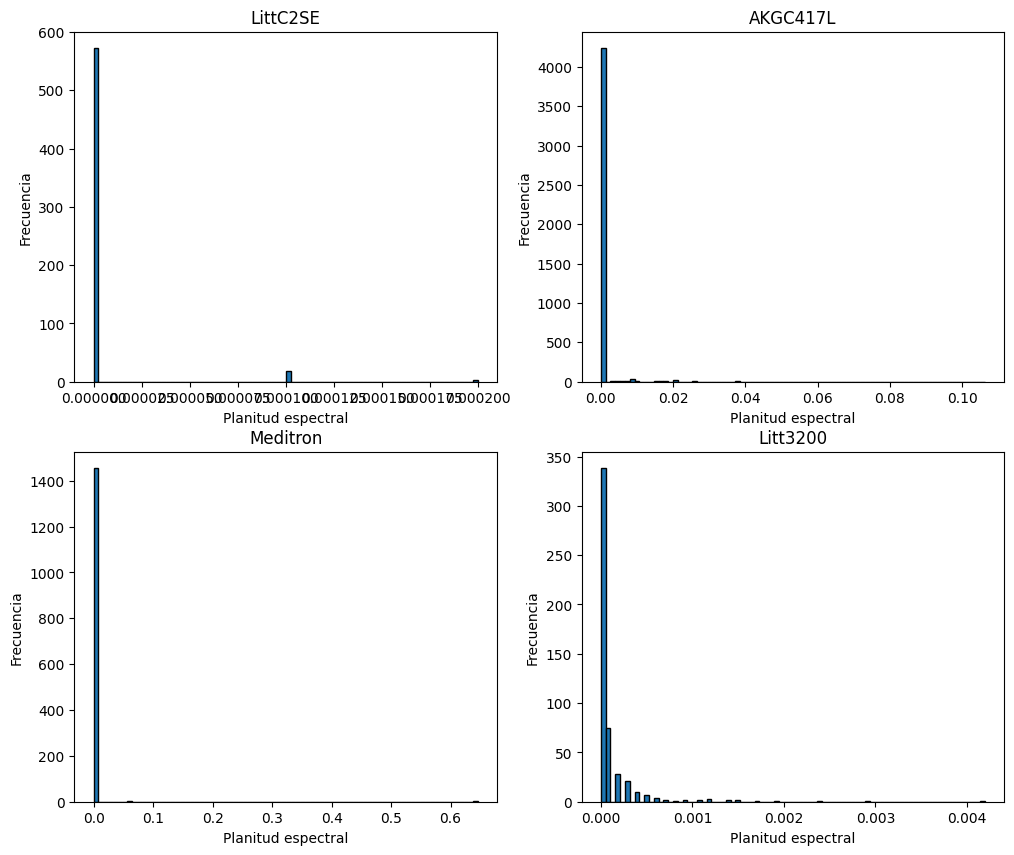

In [317]:
histograms(df, "spectral_flatness", "Planitud espectral", bins=80)

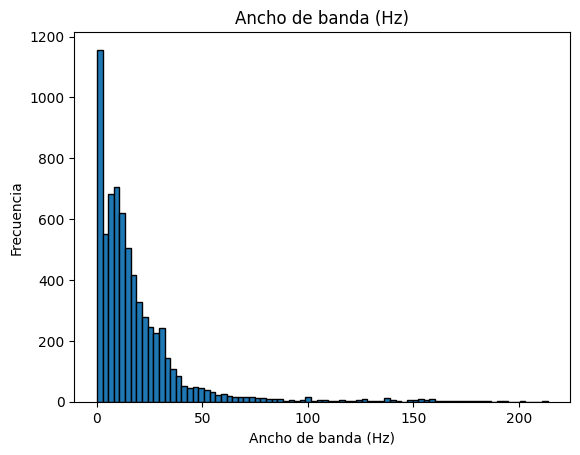

<Figure size 640x480 with 0 Axes>

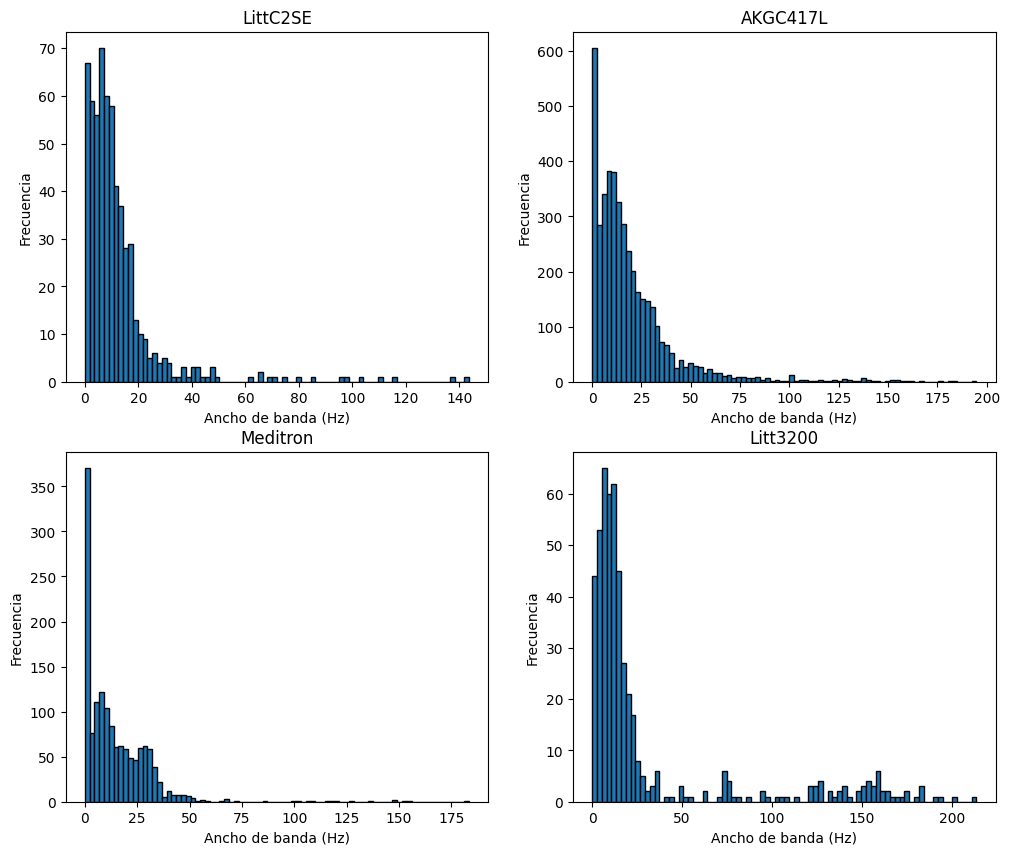

In [318]:
histograms(df, "bandwidth_hz", "Ancho de banda (Hz)", bins=80)

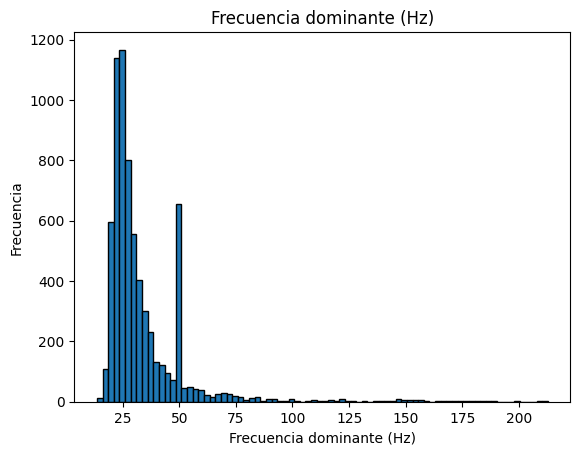

<Figure size 640x480 with 0 Axes>

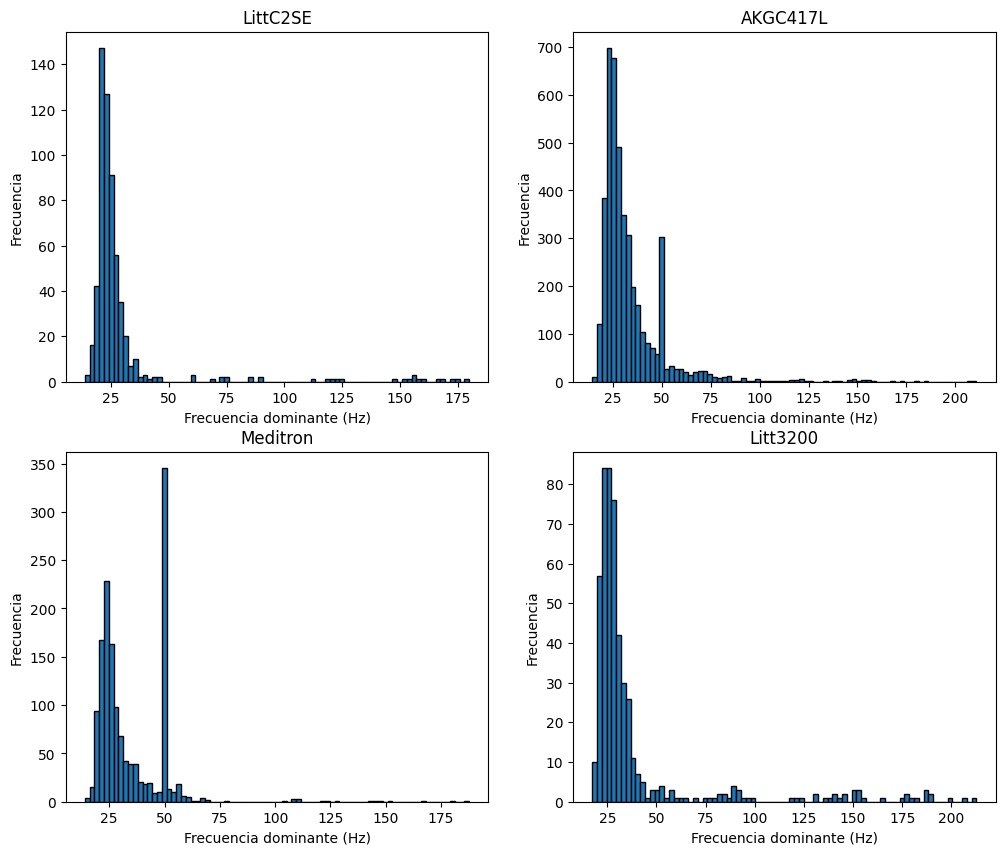

In [319]:
histograms(df, "dom_freq_hz", "Frecuencia dominante (Hz)", bins=80)

# Conclusiones
---

SNR:
* Valor mínimo de SNR 1.2 dB

Duración: 
* Tiempo mínimo de 0.5s

Análisi espectral:
* Filtrado de 20Hz a 250 Hz
* Con Meditron y AKG, filtro de alta calidad a 50Hz (Señal eléctrica)